# Cross-section — OI/vol/liq → severity (Phase 3a)

Tee & Ting §4.3. Size proxy = log daily notional (true OI unavailable).


## Pass 1 claim test
Paper: larger/thicker → smaller \(|\Delta P|\), more \(i_c\), longer \(\Delta t\).
Crypto: NW-OLS on gated events; quintiles by log notional.



In [1]:
from pathlib import Path
import json
OUT = Path('../../out/phase3a_stats_xsec').resolve()
s = json.loads((OUT / 'phase3a_summary.json').read_text())
p = s['pooled']
print('cells', p['n_cells'], 'raw', p['n_ssm_raw'], 'gated', p['n_ssm_gated'], 'nanex', p['n_nanex'])
print('gate', p.get('gate_ablation_totals'))
print('ssm_dp', p['ssm_dp'])
print('class', p['ssm_class'])
print('markout', p.get('ssm_markout_mean_bps'))
print('dt_mo', p.get('spearman_dt_mo5_cell_mean'))
print('ols', s.get('ols_event', {}).get('dp', {}).get('r2'))
print('vpin_int', (s.get('ols_event', {}).get('dp', {}) or {}).get('with_vpin_interaction', {}).get('r2'))
print('time_split', s.get('time_split'))
print('exante', s.get('ols_exante'))
print('multi_coin', s.get('multi_coin'))
print('by_venue', s.get('by_venue'))



cells=42 ssm_raw=3668 gated=275 nanex=105
gate_ablation={'5bps_ic3': {'n_raw': 3668, 'n_kept': 589}, '10bps_ic5': {'n_raw': 3668, 'n_kept': 275}, '30bps_ic10': {'n_raw': 3668, 'n_kept': 56}}
ssm_dp={'n': 275, 'mean': 0.2338371657581987, 'median': 0.17692265162824378, 'sd': 0.1500445577278157, 'p25': 0.12979357030011185, 'p75': 0.2827174869607355}
ssm_class={'n_v_recovery': 212, 'n_continuation': 39, 'n_partial': 24, 'share_v': 0.7709090909090909, 'share_continuation': 0.14181818181818182}
markout={'0.5': -4.8529595645259205, '1.0': -7.633413298911545, '5.0': -7.12819350000448}
dt_mo_spearman=-0.276027499975911
ols_r2=0.01957550628826421 vpin_r2=0.03504955813928645
time_split={'early_n': 165, 'late_n': 110, 'early_beta_logN': 0.0010321979810437483, 'late_beta_logN': -0.008326975452582236, 'early_r2': 0.042950682511061045, 'late_r2': 0.026725177569318914, 'sign_stable': 0}
exante_n=20 exante_r2=0.17508963952096224
multi_coin={'ETH': {'n_cells': 15, 'mean_median_dp': 0.19336934836180145, 

## Quintiles by size proxy


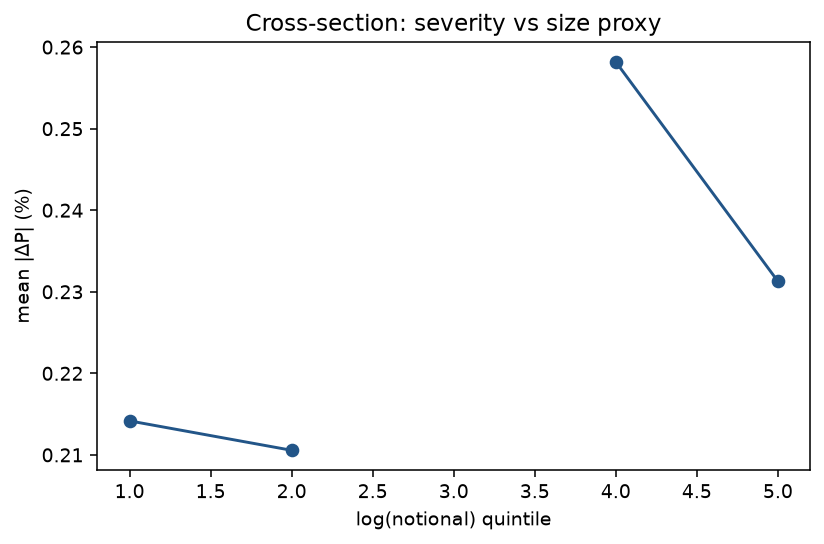

In [2]:
from IPython.display import Image
Image(filename=str(OUT/'figs/fig_quintile_size_dp.png'))


## NW-OLS forest (ΔP)


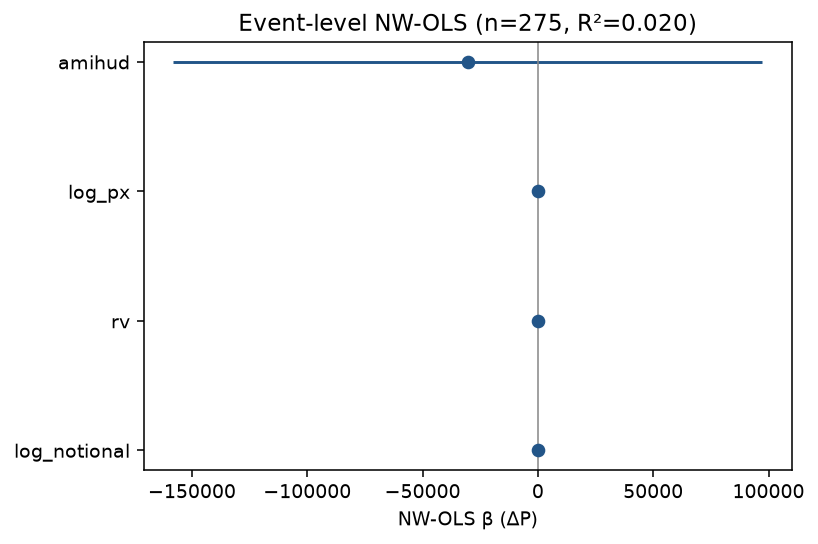

In [3]:
Image(filename=str(OUT/'figs/fig_nw_ols_dp.png'))


## Multi-coin


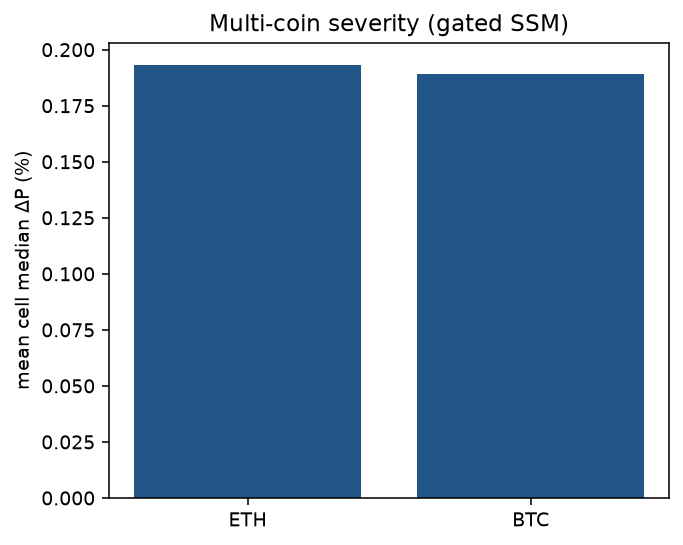

In [4]:
Image(filename=str(OUT/'figs/fig_multi_coin.png'))


### Signal board
| Object | Monitor | Tradable | Decision |
|--------|---------|----------|----------|
| size → lower ΔP | — | — | **Kill** (R²≈0.02; time-split sign flip) |
| VPIN × size | ✓ | ✗ | **Hold** (interact t≈3; needs harden) |
| ex-ante Amihud | ✓ | ✗ | **Hold** (n_pred=20) |
| ETH vs BTC severity | ✓ | — | **Hold** (parity this week) |

Ceilings: OI not wired; Kraken TOB=0 irrelevant for these regressors; ex-ante underpowered.

